# EDA – Dữ liệu Rượu Vang

**Mục tiêu:** Khám phá dữ liệu thô để xác định các bước tiền xử lý cần thiết trước khi huấn luyện mô hình dự đoán giá.

| Cột | Ý nghĩa |
|-----|---------|
| `ten` | Tên sản phẩm |
| `gia` | Giá (chuỗi, VNĐ) |
| `giong_nho` | Giống nho |
| `nha_san_xuat` | Nhà sản xuất |
| `quoc_gia` | Quốc gia |
| `nong_do` | Nồng độ cồn |
| `dung_tich` | Dung tích chai |
| `loai_ruou` | Phân loại rượu |
| `url` | URL nguồn |

In [ ]:
from google.colab import files

uploaded = files.upload()
for filename in uploaded.keys():
    print(f'Uploaded file: {filename} (size: {len(uploaded[filename])} bytes)')

Saving wines1.csv to wines1.csv
Uploaded file: wines1.csv (size: 354634 bytes)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re

In [ ]:
df = pd.read_csv('wines1.csv')
print(f"Kích thước: {df.shape[0]} dòng × {df.shape[1]} cột")
print("Dữ liệu mẫu:")
display(df.head())

Kích thước: 1579 dòng × 9 cột
Dữ liệu mẫu:


,ten,gia,giong_nho,nha_san_xuat,quoc_gia,nong_do,dung_tich,loai_ruou,url
0,Rượu Vang Pháp Château Guion Barrail Bordeaux ...,NaN,Bordeaux Blend,Château Guion Barrail,Vang Pháp,13% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/chateau-g...
1,Rượu Vang Pháp Château La Coste Le Rouge 2023,NaN,Blend,Château La Coste,Vang Pháp,14% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/chateau-l...
2,Rượu Vang Pháp La Fiole Côtes Du Rhône Rouge P...,638.000 ₫,Blend,Père Anselme,Vang Pháp,14% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/la-fiole-...
3,Rượu Vang Pháp La Fiole Du Pape Châteauneuf-Du...,1.936.000 ₫,Blend,Père Anselme,Vang Pháp,14.5% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/la-fiole-...
4,Rượu Vang Pháp Domaine Faiveley Bourgogne Pino...,1.496.000 ₫,Pinot Noir,Domaine Faiveley,Vang Pháp,13% ABV*,750ml,Rượu Vang Đỏ,https://winecellar.vn/ruou-vang-phap/domaine-f...


# Tổng quan dữ liệu

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579 entries, 0 to 1578
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ten           1579 non-null   object
 1   gia           1575 non-null   object
 2   giong_nho     1578 non-null   object
 3   nha_san_xuat  1579 non-null   object
 4   quoc_gia      1578 non-null   object
 5   nong_do       1562 non-null   object
 6   dung_tich     1562 non-null   object
 7   loai_ruou     1579 non-null   object
 8   url           1579 non-null   object
dtypes: object(9)
memory usage: 111.2+ KB


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"Missing": missing, "Tỷ lệ (%)": missing_pct}).query("Missing > 0")

,Missing,Tỷ lệ (%)
gia,4,0.25
giong_nho,1,0.06
quoc_gia,1,0.06
nong_do,17,1.08
dung_tich,17,1.08


In [ ]:
df.nunique().rename("Unique values").to_frame()

,Unique values
ten,1578
gia,641
giong_nho,57
nha_san_xuat,249
quoc_gia,11
nong_do,27
dung_tich,13
loai_ruou,6
url,1579


# I. Phân tích đơn biến

## 1. Biến mục tiêu `gia` (giá)

### a. Cột `gia` đang là chuỗi dạng `'1.936.000 ₫'`  
→ Cần làm sạch ký tự đặc biệt và chuyển về kiểu số.

In [ ]:
print("Mẫu giá trị thô:", df["gia"].dropna().head(5).tolist())

df["gia_num"] = (
    df["gia"]
    .str.replace(r"[^\d]", "", regex=True)
    .replace("", np.nan)
    .astype("float")
)

print(f"\nMissing sau parse: {df['gia_num'].isna().sum()}")
df["gia_num"].describe().apply(lambda x: f"{x:,.0f}")

Mẫu giá trị thô: ['638.000\xa0₫', '1.936.000\xa0₫', '1.496.000\xa0₫', '1.754.500\xa0₫', '1.270.500\xa0₫']

Missing sau parse: 4


,gia_num
count,"1,575"
mean,"6,832,334"
std,"10,022,298"
min,"231,000"
25%,"1,474,000"
50%,"3,327,500"
75%,"7,733,000"
max,"109,890,000"


### b. Phát hiện outliers trong `gia`

Ngưỡng dưới: 0 ₫  |  Ngưỡng trên: 17,121,500 ₫
Số outlier (IQR): 152 (9.6%)


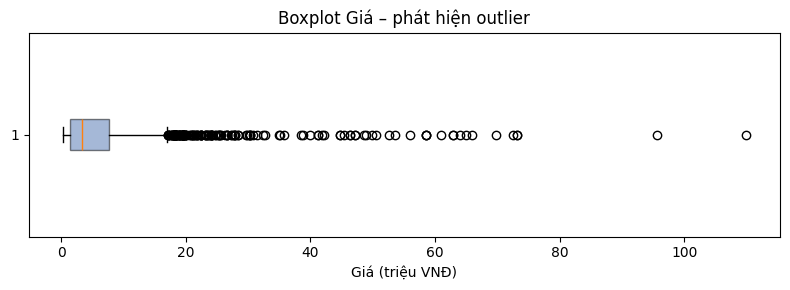

In [ ]:
Q1, Q3 = df["gia_num"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = max(0, Q1 - 1.5 * IQR), Q3 + 1.5 * IQR

outliers = df[(df["gia_num"] < lower) | (df["gia_num"] > upper)]
print(f"Ngưỡng dưới: {lower:,.0f} ₫  |  Ngưỡng trên: {upper:,.0f} ₫")
print(f"Số outlier (IQR): {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(df["gia_num"].dropna() / 1e6, vert=False, patch_artist=True,
           boxprops=dict(facecolor="#4C72B0", alpha=0.5))
ax.set_xlabel("Giá (triệu VNĐ)")
ax.set_title("Boxplot Giá – phát hiện outlier")
plt.tight_layout()
plt.show()

### c. Phân phối biến mục tiêu `gia` và Log-transform

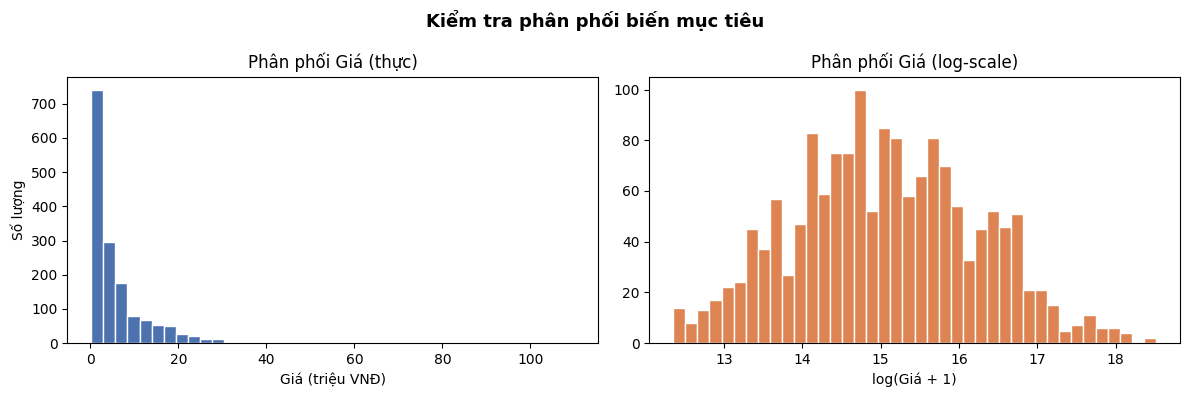

Kết luận: Phân phối lệch phải → nên dùng log-transform cho biến mục tiêu khi training.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["gia_num"].dropna() / 1e6, bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Giá (triệu VNĐ)")
axes[0].set_ylabel("Số lượng")
axes[0].set_title("Phân phối Giá (thực)")

axes[1].hist(np.log1p(df["gia_num"].dropna()), bins=40, color="#DD8452", edgecolor="white")
axes[1].set_xlabel("log(Giá + 1)")
axes[1].set_title("Phân phối Giá (log-scale)")

plt.suptitle("Kiểm tra phân phối biến mục tiêu", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Kết luận: Phân phối lệch phải → nên dùng log-transform cho biến mục tiêu khi training.")

## 2. Biến `nong_do` (Nồng độ cồn)

### a. Dạng chuỗi `'13% ABV*'` → cần extract số thực.

Mẫu: ['13% ABV*' '14% ABV*' '14.5% ABV*' '13.5% ABV*' '15% ABV*' '15.5% ABV*'
 '12.5% ABV*' '14.2% ABV*']

Missing: 17
count    1562.00
mean       13.36
std         1.85
min         0.00
25%        13.00
50%        13.50
75%        14.00
max        20.00
Name: nong_do_num, dtype: float64


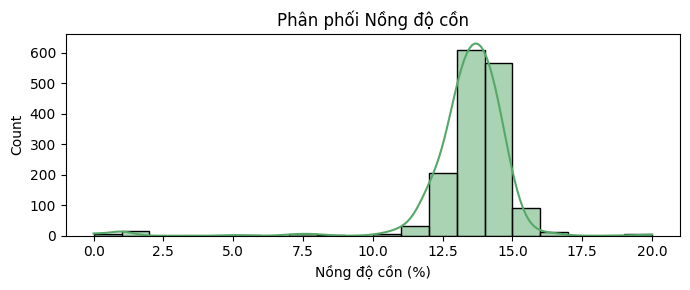

In [ ]:
print("Mẫu:", df["nong_do"].dropna().unique()[:8])

df["nong_do_num"] = (
    df["nong_do"]
    .str.extract(r"([\d.]+)")[0]
    .astype("float")
)

print(f"\nMissing: {df['nong_do_num'].isna().sum()}")
print(df["nong_do_num"].describe().round(2))

plt.figure(figsize=(7, 3))
sns.histplot(df["nong_do_num"].dropna(), bins=20, kde=True, color="#55A868")
plt.xlabel("Nồng độ cồn (%)")
plt.title("Phân phối Nồng độ cồn")
plt.tight_layout()
plt.show()

## 3. Biến `dung_tich` (Dung tích)

### a. Giá trị phức tạp như `'3L, 750ml'` → cần chuẩn hóa về đơn vị ml.

In [ ]:
print("Các giá trị unique:")
print(df["dung_tich"].value_counts().to_string())

def parse_dung_tich(val):
    if pd.isna(val):
        return np.nan
    val = str(val).split(",")[0].strip().lower()
    if "ml" in val:
        return float(val.replace("ml", "").strip())
    elif "l" in val:
        return float(val.replace("l", "").strip()) * 1000
    return np.nan

df["dung_tich_ml"] = df["dung_tich"].apply(parse_dung_tich)
print("\nSau parse (ml):")
print(df["dung_tich_ml"].value_counts())
print(f"\nMissing: {df['dung_tich_ml'].isna().sum()}")

Các giá trị unique:
dung_tich
750ml                  1455
1.5L                     40
3L                       33
6L                       10
5L                        8
500ml                     4
9L                        3
375ml                     3
12L                       2
620ml                     1
3L, 750ml                 1
15L                       1
1.5L, 1.5L Luminous       1

Sau parse (ml):
dung_tich_ml
750.0      1455
1500.0       41
3000.0       34
6000.0       10
5000.0        8
500.0         4
9000.0        3
375.0         3
12000.0       2
620.0         1
15000.0       1
Name: count, dtype: int64

Missing: 17


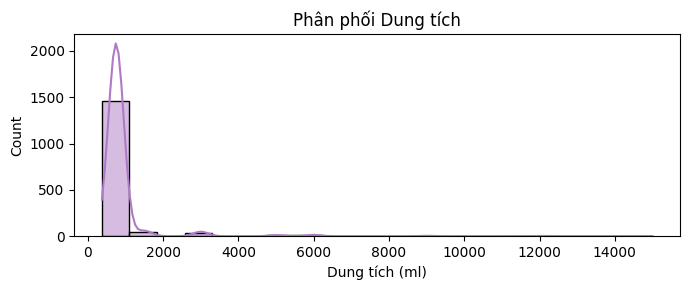

In [ ]:
plt.figure(figsize=(7, 3))
sns.histplot(df["dung_tich_ml"].dropna(), bins=20, kde=True, color="#AF7AC5")
plt.xlabel("Dung tích (ml)")
plt.title("Phân phối Dung tích")
plt.tight_layout()
plt.show()

## 4. Biến phân loại (`loai_ruou`, `quoc_gia`, `giong_nho`)

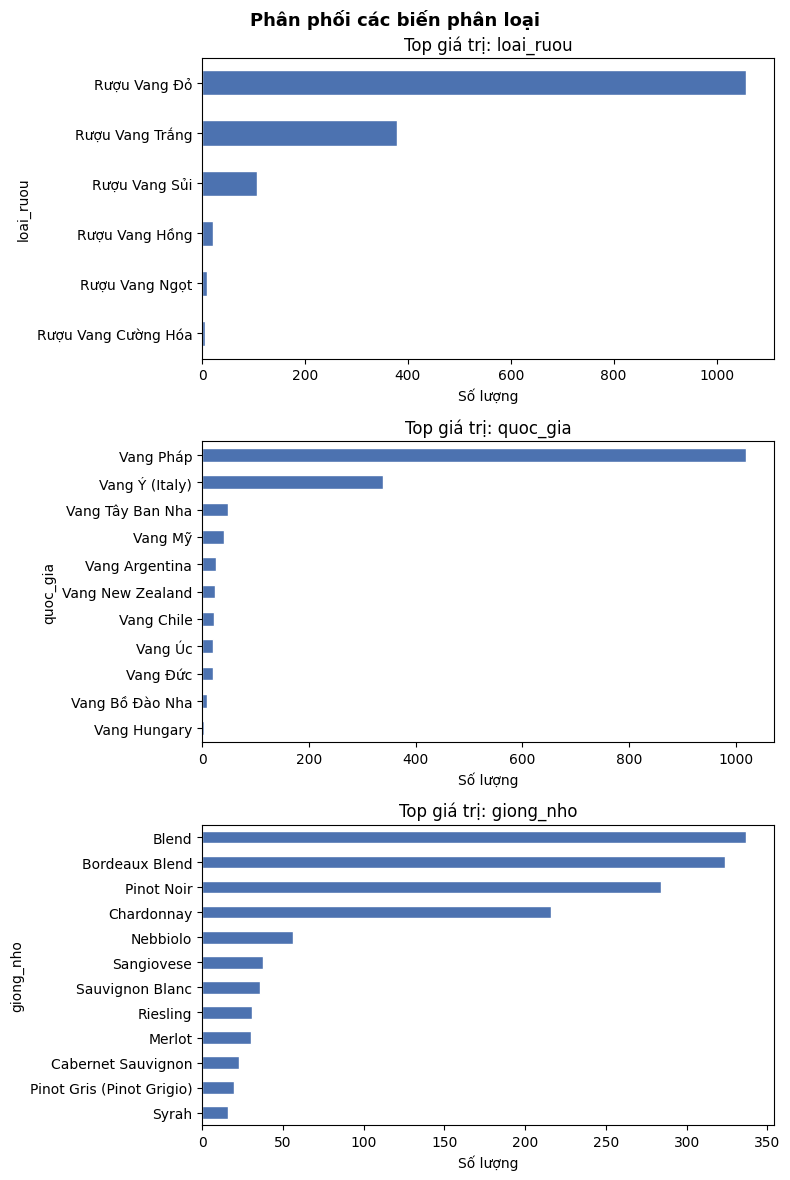

In [ ]:
cat_cols = ["loai_ruou", "quoc_gia", "giong_nho"]

fig, axes = plt.subplots(3, 1, figsize=(8, 12))
for ax, col in zip(axes.flatten(), cat_cols):
    counts = df[col].value_counts().head(12)
    counts.plot(kind="barh", ax=ax, color="#4C72B0", edgecolor="white")
    ax.set_title(f"Top giá trị: {col}")
    ax.set_xlabel("Số lượng")
    ax.invert_yaxis()
plt.suptitle("Phân phối các biến phân loại", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 5. Biến `ten`

In [ ]:
def extract_year(name):
    """Tìm năm sản xuất (4 chữ số trong khoảng 1900-2099)."""
    match = re.search(r'\b(19|20)\d{2}\b', str(name))
    return int(match.group()) if match else None

df['year'] = df['ten'].apply(extract_year)

year_found_count = df['year'].notna().sum()

total_observations = len(df)
percentage_with_year = (year_found_count / total_observations) * 100

print(f"Số lượng quan sát có năm sản xuất trong tên: {year_found_count}")
print(f"Tổng số quan sát: {total_observations}")
print(f"Phần trăm các quan sát có năm sản xuất trong tên: {percentage_with_year:.2f}%")

Số lượng quan sát có năm sản xuất trong tên: 1174
Tổng số quan sát: 1579
Phần trăm các quan sát có năm sản xuất trong tên: 74.35%


In [ ]:
# Danh sách các hạng rượu phổ biến (có thể mở rộng)
APPELLATIONS = [
    # Pháp
    r"Châteauneuf-Du-Pape",
    r"Côtes Du Rhône",
    r"Bourgogne",
    r"Mercurey",
    r"Bordeaux",
    r"Champagne",
    r"Alsace",
    r"Provence",
    r"Languedoc",
    # Ý
    r"Primitivo",
    r"Negroamaro",
    r"Barolo",
    r"Chianti",
    r"Amarone",
    r"Brunello",
    r"Prosecco",
    # Tây Ban Nha
    r"Rioja",
    r"Ribera Del Duero",
    r"Cava",
    # Khác
    r"Pinot Noir",
    r"Cabernet Sauvignon",
    r"Sauvignon Blanc",
    r"Chardonnay",
    r"Merlot",
    r"Syrah",
    r"Grenache",
]

appellation_pattern = re.compile(
    '|'.join(APPELLATIONS),
    flags=re.IGNORECASE
)

def extract_rank(name):
    """Trích xuất hạng/appellation từ tên rượu."""
    matches = appellation_pattern.findall(str(name))
    if matches:
        # Trả về tất cả match, loại trùng lặp, giữ thứ tự
        seen = []
        for m in matches:
            if m.title() not in seen:
                seen.append(m.title())
        return ', '.join(seen)
    return None

df['rank'] = df['ten'].apply(extract_rank)

# Tính số lượng quan sát có hạng rượu
rank_found_count = df['rank'].notna().sum()

# Tính tổng số quan sát
total_observations = len(df)

# Tính phần trăm
percentage_with_rank = (rank_found_count / total_observations) * 100

print(f"Số lượng quan sát có hạng rượu trong tên: {rank_found_count}")
print(f"Tổng số quan sát: {total_observations}")
print(f"Phần trăm các quan sát có hạng rượu trong tên: {percentage_with_rank:.2f}%")

Số lượng quan sát có hạng rượu trong tên: 364
Tổng số quan sát: 1579
Phần trăm các quan sát có hạng rượu trong tên: 23.05%


# II. Phân tích hai biến

## 1. Giá theo Nhóm Phân Loại

/tmp/ipykernel_6808/2026891024.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)
/tmp/ipykernel_6808/2026891024.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)


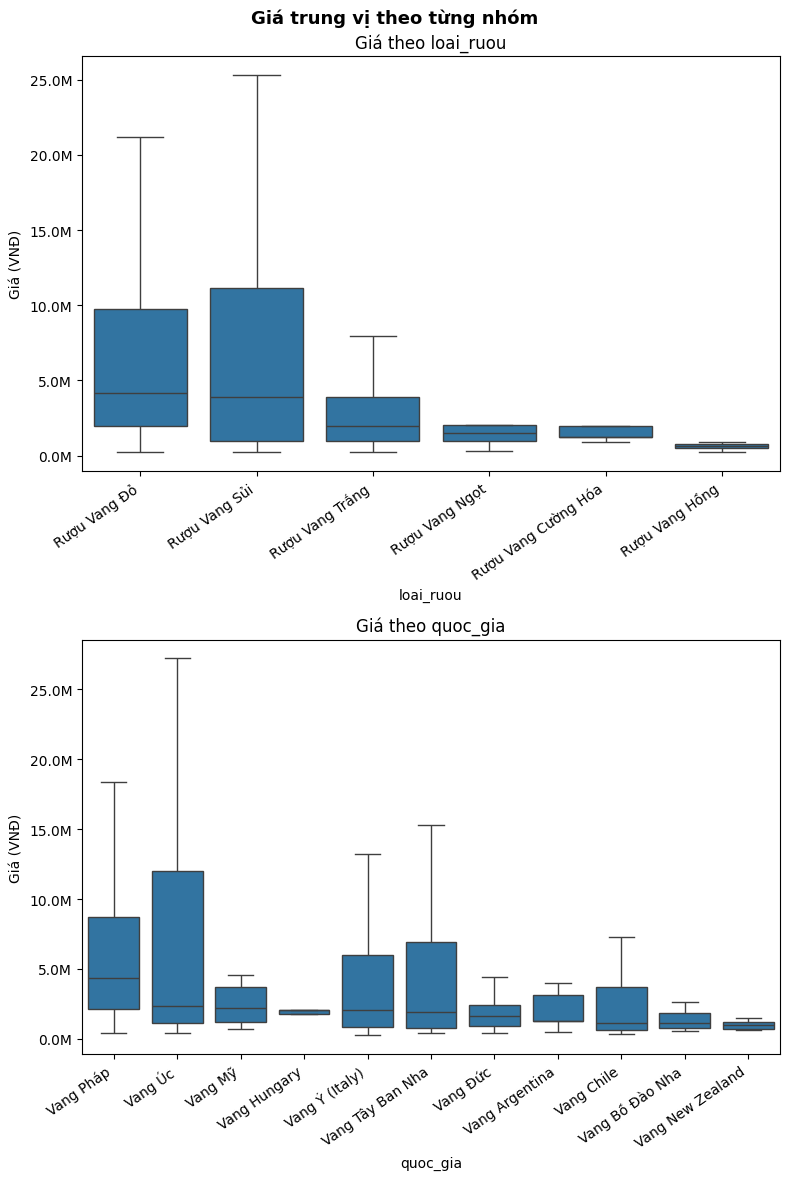

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, col in zip(axes, ["loai_ruou", "quoc_gia"]):
    order = (df.groupby(col)["gia_num"].median()
               .sort_values(ascending=False).index)
    sns.boxplot(data=df, x=col, y="gia_num", order=order, ax=ax,
                showfliers=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
    ax.set_ylabel("Giá (VNĐ)")
    ax.set_title(f"Giá theo {col}")

plt.suptitle("Giá trung vị theo từng nhóm", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Tương quan Nồng độ vs Giá

Ma trận tương quan:
              gia_num  nong_do_num  dung_tich_ml
gia_num         1.000        0.075         0.470
nong_do_num     0.075        1.000         0.026
dung_tich_ml    0.470        0.026         1.000


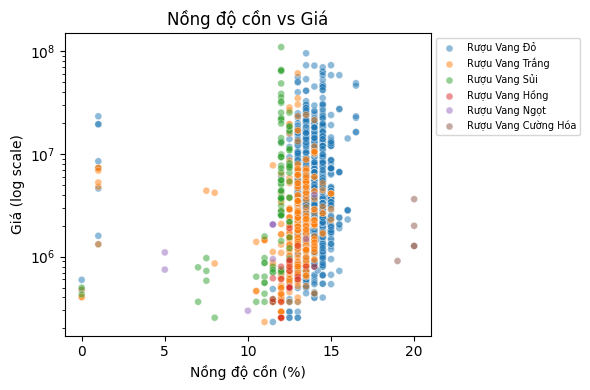

In [ ]:
corr = df[["gia_num", "nong_do_num", "dung_tich_ml"]].corr()
print("Ma trận tương quan:")
print(corr.round(3))

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="nong_do_num", y="gia_num",
                hue="loai_ruou", alpha=0.5, s=25)
plt.yscale("log")
plt.xlabel("Nồng độ cồn (%)")
plt.ylabel("Giá (log scale)")
plt.title("Nồng độ cồn vs Giá")
plt.legend(bbox_to_anchor=(1, 1), fontsize=7)
plt.tight_layout()
plt.show()

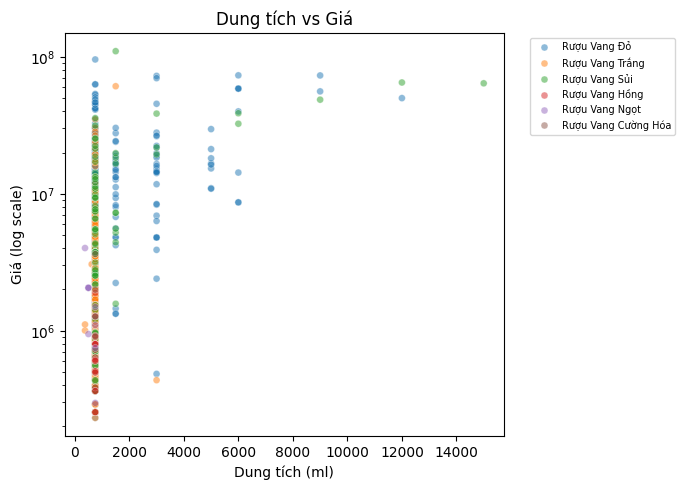

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="dung_tich_ml", y="gia_num", hue="loai_ruou", alpha=0.5, s=25)
plt.yscale("log")
plt.xlabel("Dung tích (ml)")
plt.ylabel("Giá (log scale)")
plt.title("Dung tích vs Giá")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
df.to_excel("data.xlsx", index=False)
print("Dữ liệu đã được xuất thành công ra file data.xlsx")

Dữ liệu đã được xuất thành công ra file data.xlsx
